Computing ECC for all 4096 kernels...
  500/4096 done
  1000/4096 done
  1500/4096 done
  2000/4096 done
  2500/4096 done
  3000/4096 done
  3500/4096 done
  4000/4096 done


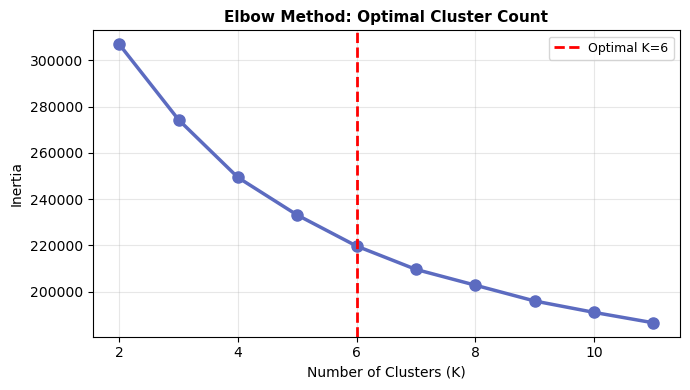


Clustering with K=6:
  Cluster 0: 889 kernels
  Cluster 1: 566 kernels
  Cluster 2: 427 kernels
  Cluster 3: 309 kernels
  Cluster 4: 1402 kernels | Kernel 42 (Robust), Kernel 806 (Vulnerable)
  Cluster 5: 503 kernels

Most redundant pairs per cluster:
  Cluster 0: Kernel 1771 <-> Kernel 3229  ECC L2=1.7321
  Cluster 1: Kernel 1063 <-> Kernel 3113  ECC L2=8.2462
  Cluster 2: Kernel 238 <-> Kernel 1365  ECC L2=7.8102
  Cluster 3: Kernel 2122 <-> Kernel 425  ECC L2=8.3666
  Cluster 4: Kernel 2545 <-> Kernel 2570  ECC L2=2.6458
  Cluster 5: Kernel 3265 <-> Kernel 1245  ECC L2=8.1240


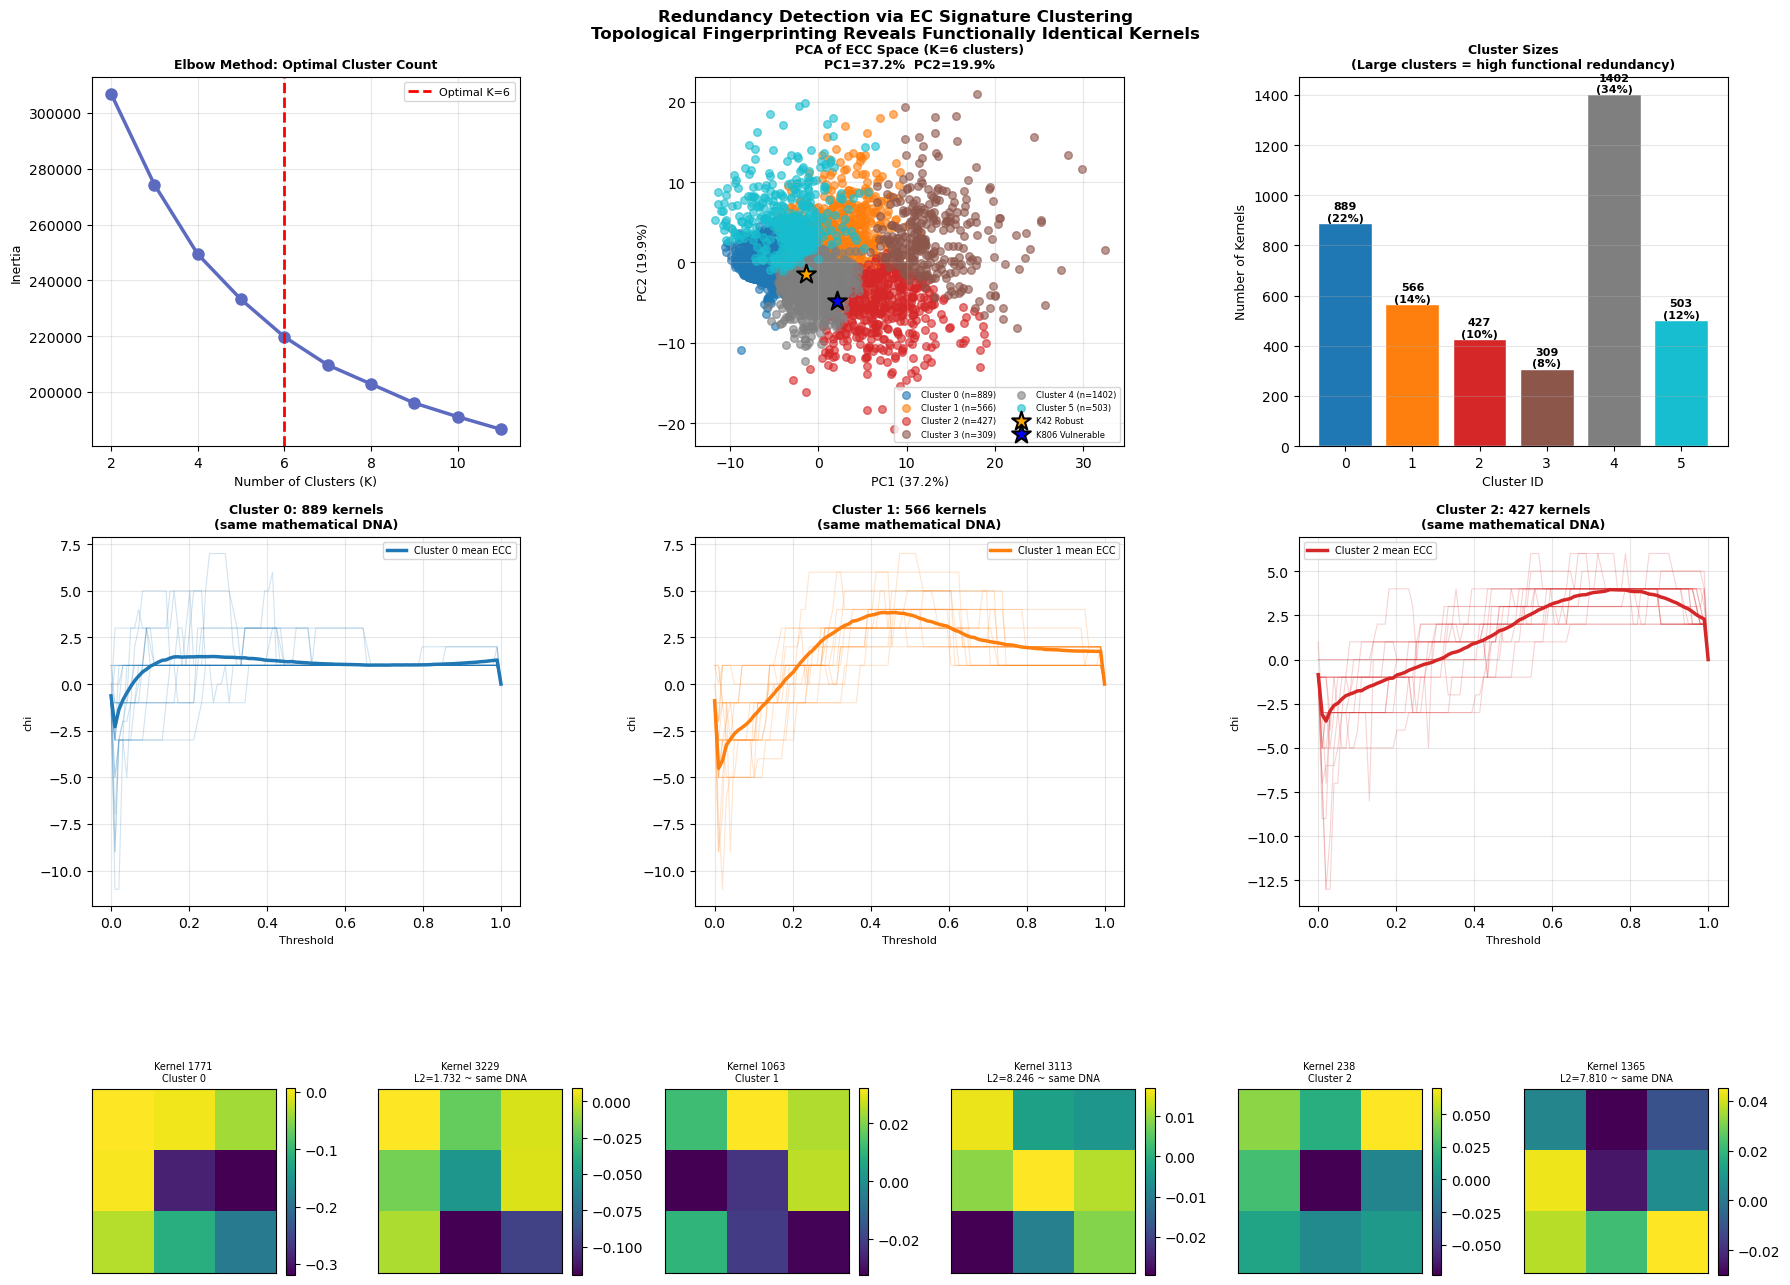

Saved: RedundancyClustering.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sharedfunctions import (loadKernels, computeSigma, computeMagnitudeResponse,
                              calculateEcc, eccL2Distance, eccWassersteinDistance,
                              IDXROBUST, IDXVULNERABLE, GRIDSIZE, SIGMAGRID, NTHRESH, CSVPATH)

# ============================================================
# Load kernels and compute ECC for all
# ============================================================
kernels = loadKernels(CSVPATH)

print("Computing ECC for all 4096 kernels...")
eccs = []
for i, h in enumerate(kernels):
    mag = computeMagnitudeResponse(h)
    _, ecc = calculateEcc(mag)
    eccs.append(ecc)
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{len(kernels)} done")
eccs = np.array(eccs)

# ============================================================
# Scale and find optimal K via elbow method
# ============================================================
scaler = StandardScaler()
eccsScaled = scaler.fit_transform(eccs)

KRange = range(2, 12)
inertias = []
for k in KRange:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(eccsScaled)
    inertias.append(km.inertia_)

# Quick elbow plot
plt.figure(figsize=(7, 4))
plt.plot(list(KRange), inertias, 'o-', color='#5c6bc0', linewidth=2.5, markersize=8)
plt.axvline(6, color='red', linewidth=2, linestyle='--', label='Optimal K=6')
plt.title("Elbow Method: Optimal Cluster Count", fontsize=11, fontweight='bold')
plt.xlabel("Number of Clusters (K)", fontsize=10)
plt.ylabel("Inertia", fontsize=10)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final clustering with optimal K
# ============================================================
optimalK = 6
kmeans = KMeans(n_clusters=optimalK, random_state=42, n_init=10)
labels = kmeans.fit_predict(eccsScaled)
clusterSizes = [int(np.sum(labels == c)) for c in range(optimalK)]

# Find most redundant pair per cluster
redundantPairs = []
for c in range(optimalK):
    members = np.where(labels == c)[0]
    if len(members) < 2:
        continue
    dists = np.linalg.norm(eccsScaled[members] - kmeans.cluster_centers_[c], axis=1)
    sortedM = members[np.argsort(dists)]
    redundantPairs.append((sortedM[0], sortedM[1], c))

# Print cluster summary
print(f"\nClustering with K={optimalK}:")
for c in range(optimalK):
    members = np.where(labels == c)[0]
    notes = []
    if IDXROBUST in members:
        notes.append(f"Kernel {IDXROBUST} (Robust)")
    if IDXVULNERABLE in members:
        notes.append(f"Kernel {IDXVULNERABLE} (Vulnerable)")
    noteStr = " | " + ", ".join(notes) if notes else ""
    print(f"  Cluster {c}: {len(members):3d} kernels{noteStr}")

print(f"\nMost redundant pairs per cluster:")
for k1, k2, c in redundantPairs:
    d = eccL2Distance(eccs[k1], eccs[k2])
    print(f"  Cluster {c}: Kernel {k1} <-> Kernel {k2}  ECC L2={d:.4f}")

# ============================================================
# PCA for visualization
# ============================================================
pca = PCA(n_components=2)
eccsPca = pca.fit_transform(eccsScaled)
var = pca.explained_variance_ratio_

# ============================================================
# Full figure
# ============================================================
clusterColors = plt.cm.tab10(np.linspace(0, 0.9, optimalK))
tSpace = np.linspace(0, 1, NTHRESH)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Redundancy Detection via EC Signature Clustering\n"
             "Topological Fingerprinting Reveals Functionally Identical Kernels",
             fontsize=12, fontweight='bold')

# Panel 1: Elbow curve
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(list(KRange), inertias, 'o-', color='#5c6bc0', linewidth=2.5, markersize=8)
ax1.axvline(optimalK, color='red', linewidth=2, linestyle='--',
            label=f'Optimal K={optimalK}')
ax1.set_title("Elbow Method: Optimal Cluster Count", fontsize=9, fontweight='bold')
ax1.set_xlabel("Number of Clusters (K)", fontsize=9)
ax1.set_ylabel("Inertia", fontsize=9)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: PCA scatter
ax2 = fig.add_subplot(3, 3, 2)
for c in range(optimalK):
    mask = labels == c
    ax2.scatter(eccsPca[mask, 0], eccsPca[mask, 1],
                color=clusterColors[c], alpha=0.6, s=30,
                label=f'Cluster {c} (n={clusterSizes[c]})')
ax2.scatter(eccsPca[IDXROBUST, 0], eccsPca[IDXROBUST, 1],
            color='orange', s=200, zorder=5, marker='*',
            edgecolors='black', linewidths=1.5,
            label=f'K{IDXROBUST} Robust')
ax2.scatter(eccsPca[IDXVULNERABLE, 0], eccsPca[IDXVULNERABLE, 1],
            color='blue', s=200, zorder=5, marker='*',
            edgecolors='black', linewidths=1.5,
            label=f'K{IDXVULNERABLE} Vulnerable')
ax2.set_title(f"PCA of ECC Space (K={optimalK} clusters)\n"
              f"PC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%",
              fontsize=9, fontweight='bold')
ax2.set_xlabel(f"PC1 ({var[0]*100:.1f}%)", fontsize=9)
ax2.set_ylabel(f"PC2 ({var[1]*100:.1f}%)", fontsize=9)
ax2.legend(fontsize=6, ncol=2)
ax2.grid(True, alpha=0.3)

# Panel 3: Cluster sizes
ax3 = fig.add_subplot(3, 3, 3)
bars = ax3.bar(range(optimalK), clusterSizes,
               color=clusterColors, edgecolor='white')
for bar, size in zip(bars, clusterSizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{size}\n({100*size/len(kernels):.0f}%)',
             ha='center', va='bottom', fontsize=8, fontweight='bold')
ax3.set_title("Cluster Sizes\n(Large clusters = high functional redundancy)",
              fontsize=9, fontweight='bold')
ax3.set_xlabel("Cluster ID", fontsize=9)
ax3.set_ylabel("Number of Kernels", fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Panels 4-6: Mean ECC curves per cluster
for pi, c in enumerate(range(min(3, optimalK))):
    ax = fig.add_subplot(3, 3, 4 + pi)
    members = np.where(labels == c)[0]
    for m in members[:20]:
        ax.plot(tSpace, eccs[m], color=clusterColors[c], alpha=0.2, linewidth=0.8)
    meanEcc = np.mean(eccs[members], axis=0)
    ax.plot(tSpace, meanEcc, color=clusterColors[c],
            linewidth=2.5, label=f'Cluster {c} mean ECC')
    for si, sc, sl in [(IDXROBUST, 'orange', f'K{IDXROBUST}'),
                       (IDXVULNERABLE, 'blue', f'K{IDXVULNERABLE}')]:
        if si in members:
            ax.plot(tSpace, eccs[si], color=sc, linewidth=2.5,
                    linestyle='--', label=sl, zorder=5)
    ax.set_title(f"Cluster {c}: {len(members)} kernels\n(same mathematical DNA)",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel("Threshold", fontsize=8)
    ax.set_ylabel("chi", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Panels 7-12: Redundant kernel pairs
for pi, (k1, k2, c) in enumerate(redundantPairs[:3]):
    ax = fig.add_subplot(3, 6, 13 + pi*2)
    im = ax.imshow(kernels[k1], cmap='viridis')
    ax.set_title(f"Kernel {k1}\nCluster {c}", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = fig.add_subplot(3, 6, 14 + pi*2)
    d = eccL2Distance(eccs[k1], eccs[k2])
    im = ax.imshow(kernels[k2], cmap='viridis')
    ax.set_title(f"Kernel {k2}\nL2={d:.3f} ~ same DNA", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("RedundancyClustering.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RedundancyClustering.png")